# 🧠 ML Foundations: Classification, Logistic Regression & Imbalanced Datasets
### A Hands-On Tutorial Using Real Heart Disease Data

**Dataset:** UCI Heart Disease Dataset (`heart_disease_uci.csv`)  
**Duration:** ~115 minutes  
**Level:** Beginner → Intermediate

---

> **Learning Objectives**
> - Understand what classification is and how it differs from regression  
> - Implement and interpret logistic regression end-to-end  
> - Identify and handle imbalanced datasets using multiple techniques  
> - Build a complete baseline classification pipeline

---


---
## 📚 Section 1 — Introduction to Classification *(~25 mins)*

---

### 1.1 What Is Classification?

In supervised machine learning, we train a model on labelled examples so it can predict the label of new, unseen inputs.

**Classification** is the task of predicting a **discrete category (class)** for an input.  
**Regression** is the task of predicting a **continuous numeric value**.

| Feature | Classification | Regression |
|---------|---------------|------------|
| Output type | Category / Label | Number |
| Example output | "Has heart disease" / "No heart disease" | Blood pressure = 142 mmHg |
| Loss function | Cross-entropy | Mean squared error |
| Evaluation metric | Accuracy, F1, AUC-ROC | RMSE, MAE, R² |
| Algorithms | Logistic Reg, Decision Trees, SVM | Linear Reg, Ridge, SVR |

---

### 1.2 Binary vs. Multiclass Classification

- **Binary classification**: exactly **2 classes** — e.g., disease present vs. absent, spam vs. not spam, fraud vs. legitimate.
- **Multiclass classification**: **3 or more classes** — e.g., severity level 0/1/2/3/4, crop type, handwritten digit recognition.

Our heart disease dataset contains both:
- A **binary** version: `target` — 0 (no disease) vs. 1 (disease present)
- A **multiclass** version: `num` — severity levels 0 through 4

---

### 1.3 Real-World Classification Applications in Nigeria

Classification is already powering solutions across Africa:

| Domain | Task | Classes |
|--------|------|---------|
| 🏥 Healthcare | Malaria/typhoid diagnosis from symptoms | Malaria / Typhoid / Healthy |
| 🏦 Fintech | Loan default prediction (e.g., Moniepoint, PiggyVest) | Default / No default |
| 📱 Telecoms | Customer churn (MTN, Airtel) | Churns / Stays |
| 🌾 Agriculture | Crop disease from leaf images | Healthy / Blight / Rust |
| 🔐 Fraud Detection | Flagging suspicious USSD/transfer transactions | Fraud / Legitimate |
| 🗳️ NLP | Sentiment on political tweets in Yoruba/Igbo/Hausa | Positive / Neutral / Negative |

---

### 1.4 Overview of Classification Algorithms

You will encounter many classification algorithms in your journey. Here is how they relate:

```
Classification Algorithms
│
├── Linear Models
│   ├── Logistic Regression          ← We focus here today
│   └── Linear SVM
│
├── Tree-Based Models
│   ├── Decision Tree
│   ├── Random Forest
│   └── Gradient Boosting (XGBoost, LightGBM)
│
├── Probabilistic Models
│   └── Naive Bayes
│
├── Distance-Based
│   └── K-Nearest Neighbours (KNN)
│
└── Neural Networks
    └── Multi-Layer Perceptron (MLP)
```

Each has trade-offs between **interpretability**, **performance**, and **data requirements**.  
We start with **Logistic Regression** because it is fast, interpretable, and a strong baseline.

---


In [1]:
# ── Setup: import all libraries we need for the entire notebook ──────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    auc, ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/Dr_Wale Accelerator Programme/Week 4/Day 1/heart_disease_uci.csv'

In [4]:
# ── Load the UCI Heart Disease dataset ───────────────────────────────────────
df_raw = pd.read_csv(data_path)

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns\n")
print("Columns and types:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
df_raw.head()


Dataset shape: 920 rows × 16 columns

Columns and types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Target column 'num' — value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


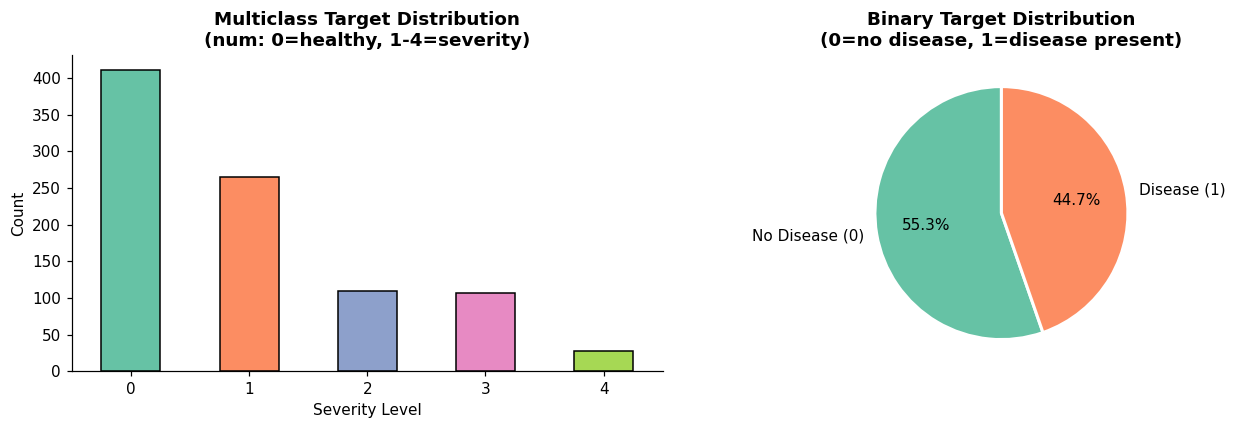


Binary class ratio — No Disease: 411 | Disease: 509


In [5]:
# ── Understanding the target variable ────────────────────────────────────────
# 'num' column: 0 = no heart disease, 1-4 = increasing severity

print("Target column 'num' — value counts:")
print(df_raw['num'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Multiclass distribution
df_raw['num'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette("Set2"), edgecolor='black'
)
axes[0].set_title("Multiclass Target Distribution\n(num: 0=healthy, 1-4=severity)", fontweight='bold')
axes[0].set_xlabel("Severity Level"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Binary version: 0 vs 1+
df_raw['target'] = (df_raw['num'] > 0).astype(int)
binary_counts = df_raw['target'].value_counts()
colors = ['#66c2a5', '#fc8d62']
axes[1].pie(binary_counts, labels=['No Disease (0)', 'Disease (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Binary Target Distribution\n(0=no disease, 1=disease present)", fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(f"\nBinary class ratio — No Disease: {binary_counts[0]} | Disease: {binary_counts[1]}")


---
### 1.5 Feature Overview

The UCI Heart Disease dataset contains 16 columns of clinical measurements:

| Column | Type | Description |
|--------|------|-------------|
| `age` | Numeric | Patient age in years |
| `sex` | Categorical | Male / Female |
| `cp` | Categorical | Chest pain type (typical angina, asymptomatic, etc.) |
| `trestbps` | Numeric | Resting blood pressure (mm Hg) |
| `chol` | Numeric | Serum cholesterol (mg/dl) |
| `fbs` | Boolean | Fasting blood sugar > 120 mg/dl |
| `restecg` | Categorical | Resting ECG results |
| `thalch` | Numeric | Maximum heart rate achieved |
| `exang` | Boolean | Exercise induced angina |
| `oldpeak` | Numeric | ST depression induced by exercise |
| `slope` | Categorical | Slope of peak exercise ST segment |
| `ca` | Numeric | Number of major vessels (0–3) coloured by fluoroscopy |
| `thal` | Categorical | Thalassemia type |
| `num` | Target | Diagnosis of heart disease (0–4) |

---


---
## 📚 Section 2 — Logistic Regression *(~60 mins)*

---

### 2.1 Why Not Linear Regression for Classification?

Suppose we try to predict heart disease (0 or 1) with linear regression.  
The model would produce outputs like `−0.3` or `1.7` — numbers that have no probabilistic meaning.  
We need a model that always outputs a value **between 0 and 1** — a *probability*.

---

### 2.2 The Sigmoid Function

The **sigmoid function** squashes any real number into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
- $z = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n$ — the linear combination of inputs
- $w_i$ — learned weights (coefficients)
- $\sigma(z)$ — the predicted **probability** that the sample belongs to class 1

**Interpretation:**
- If $\sigma(z) \geq 0.5$ → predict class **1** (disease)  
- If $\sigma(z) < 0.5$ → predict class **0** (no disease)

The threshold 0.5 is the **decision boundary** and can be adjusted.

---

### 2.3 The Decision Boundary

In 2D feature space, the decision boundary is the line (or curve) that separates the two classes.  
For logistic regression the boundary is always a **hyperplane** (linear separator):

$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

---


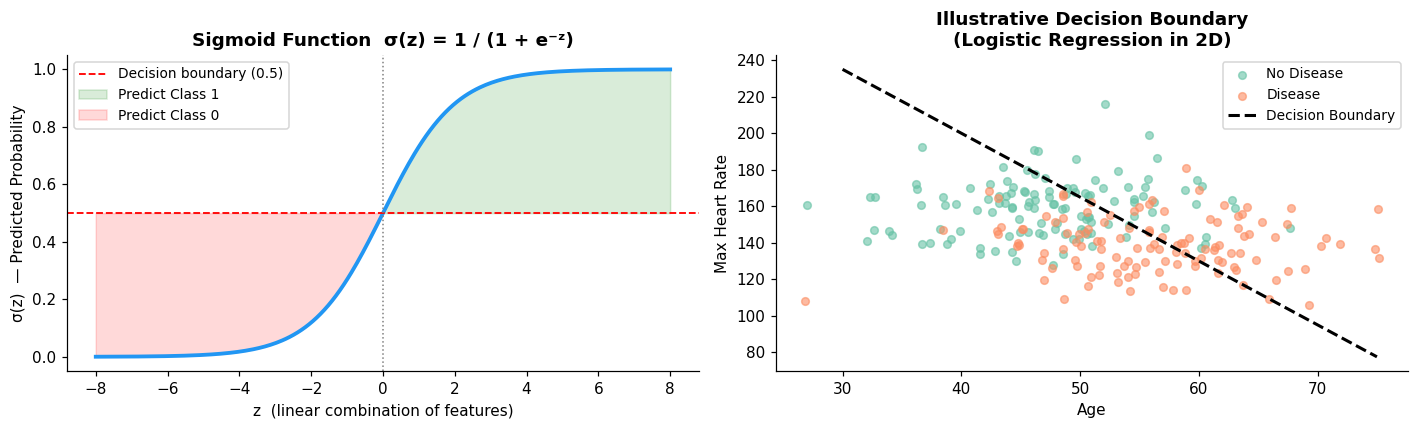

In [6]:
# ── Visualising the Sigmoid Function ─────────────────────────────────────────
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid curve
axes[0].plot(z, sigmoid, color='#2196F3', linewidth=2.5)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Decision boundary (0.5)')
axes[0].axvline(0, color='gray', linestyle=':', linewidth=1)
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid >= 0.5), alpha=0.15, color='green', label='Predict Class 1')
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.15, color='red', label='Predict Class 0')
axes[0].set_title("Sigmoid Function  σ(z) = 1 / (1 + e⁻ᶻ)", fontweight='bold')
axes[0].set_xlabel("z  (linear combination of features)")
axes[0].set_ylabel("σ(z)  — Predicted Probability")
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.05)

# Decision boundary in 2D feature space (illustrative)
np.random.seed(42)
n = 120
age_0 = np.random.normal(48, 8, n)
hr_0  = np.random.normal(158, 15, n)
age_1 = np.random.normal(56, 9, n)
hr_1  = np.random.normal(138, 14, n)

axes[1].scatter(age_0, hr_0, alpha=0.6, s=25, color='#66c2a5', label='No Disease')
axes[1].scatter(age_1, hr_1, alpha=0.6, s=25, color='#fc8d62', label='Disease')
x_line = np.linspace(30, 75, 100)
axes[1].plot(x_line, -3.5 * x_line + 340, 'k--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel("Age"); axes[1].set_ylabel("Max Heart Rate")
axes[1].set_title("Illustrative Decision Boundary\n(Logistic Regression in 2D)", fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('sigmoid_boundary.png', bbox_inches='tight')
plt.show()


---
### 2.4 Data Preprocessing

Before training logistic regression, we must:
1. **Handle missing values** — drop or impute
2. **Encode categorical variables** — convert strings to numbers
3. **Scale numerical features** — logistic regression is sensitive to feature scale
4. **Create the binary target** — `num > 0` → 1 (disease), 0 (no disease)

---


In [7]:
# ── Full Preprocessing Pipeline ──────────────────────────────────────────────

df = df_raw.copy()

# 1. Create binary target
df['target'] = (df['num'] > 0).astype(int)

# 2. Drop columns with >50% missing values (ca, thal, slope) and id/dataset
high_missing = ['ca', 'thal', 'slope', 'id', 'dataset', 'num']
df.drop(columns=high_missing, inplace=True)

print(f"Columns after dropping high-missing: {df.columns.tolist()}")

# 3. Drop remaining rows with any NaN
df.dropna(inplace=True)
print(f"Shape after dropping NaN rows: {df.shape}")

# 4. Encode boolean columns (stored as strings 'TRUE'/'FALSE')
for col in ['fbs', 'exang']:
    df[col] = df[col].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})

# 5. Encode remaining categorical columns with LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 6. Verify no remaining NaN
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"Final dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}")
df.head()


Columns after dropping high-missing: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'target']
Shape after dropping NaN rows: (740, 11)

Categorical columns to encode: ['sex', 'cp', 'restecg']

Missing values remaining: 0
Final dataset shape: (740, 11)

Class distribution:
target
1    383
0    357
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,target
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,0


In [8]:
# ── Train/Test Split & Feature Scaling ───────────────────────────────────────

X = df.drop(columns=['target'])
y = df['target']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler: transforms each feature to mean=0, std=1
# This is important for logistic regression so no single feature dominates
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = scaler.transform(X_test)        # transform test (DO NOT re-fit!)

print(f"Training samples: {X_train_sc.shape[0]}")
print(f"Test samples:     {X_test_sc.shape[0]}")
print(f"Features:         {X_train_sc.shape[1]}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())


Training samples: 592
Test samples:     148
Features:         10

Class distribution in training set:
target
1    306
0    286
Name: count, dtype: int64


---
### 2.5 Training and Evaluating the Logistic Regression Model

#### Key Evaluation Metrics

| Metric | Formula | When to use |
|--------|---------|-------------|
| **Accuracy** | (TP+TN) / Total | Balanced classes |
| **Precision** | TP / (TP+FP) | When false positives are costly |
| **Recall (Sensitivity)** | TP / (TP+FN) | When false negatives are costly (e.g., disease!) |
| **F1-Score** | 2 × P×R / (P+R) | Balance of precision and recall |
| **AUC-ROC** | Area under ROC curve | Overall discriminative ability |

> ⚠️ **In medical diagnosis**, missing a sick patient (False Negative) is often worse than a false alarm.  
> So we pay close attention to **Recall** for the positive (disease) class.

---


In [9]:
# ── Train Logistic Regression ─────────────────────────────────────────────────

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

y_pred      = lr_model.predict(X_test_sc)
y_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]   # P(class=1)

print("=" * 55)
print("       LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


       LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.80      0.80      0.80        71
     Disease       0.82      0.82      0.82        77

    accuracy                           0.81       148
   macro avg       0.81      0.81      0.81       148
weighted avg       0.81      0.81      0.81       148



In [10]:
y_pred

array([0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1])

In [11]:
y_pred_prob

array([0.28785701, 0.6966034 , 0.55337566, 0.09572862, 0.96273024,
       0.68691879, 0.66398223, 0.21493261, 0.86419227, 0.92205718,
       0.91652474, 0.6506614 , 0.52978929, 0.13604758, 0.87868928,
       0.79450508, 0.95863751, 0.38274064, 0.1665758 , 0.13067983,
       0.16886984, 0.04588756, 0.81533676, 0.86112573, 0.90152988,
       0.30108963, 0.68270999, 0.82717308, 0.4191375 , 0.82121277,
       0.66865397, 0.89514446, 0.22208466, 0.3692529 , 0.38078371,
       0.33323758, 0.77810569, 0.08343911, 0.47521969, 0.13213156,
       0.00789491, 0.55950761, 0.45589762, 0.8860792 , 0.11882574,
       0.7774512 , 0.98825758, 0.1047397 , 0.87401768, 0.4417516 ,
       0.60795637, 0.16504065, 0.96979166, 0.07318262, 0.35796508,
       0.07813561, 0.91397533, 0.12383472, 0.20102425, 0.97716271,
       0.88002181, 0.90931393, 0.80715168, 0.43645265, 0.95645428,
       0.08898982, 0.07056664, 0.20459729, 0.13585221, 0.31856937,
       0.4665596 , 0.8862715 , 0.889081  , 0.42209721, 0.87851

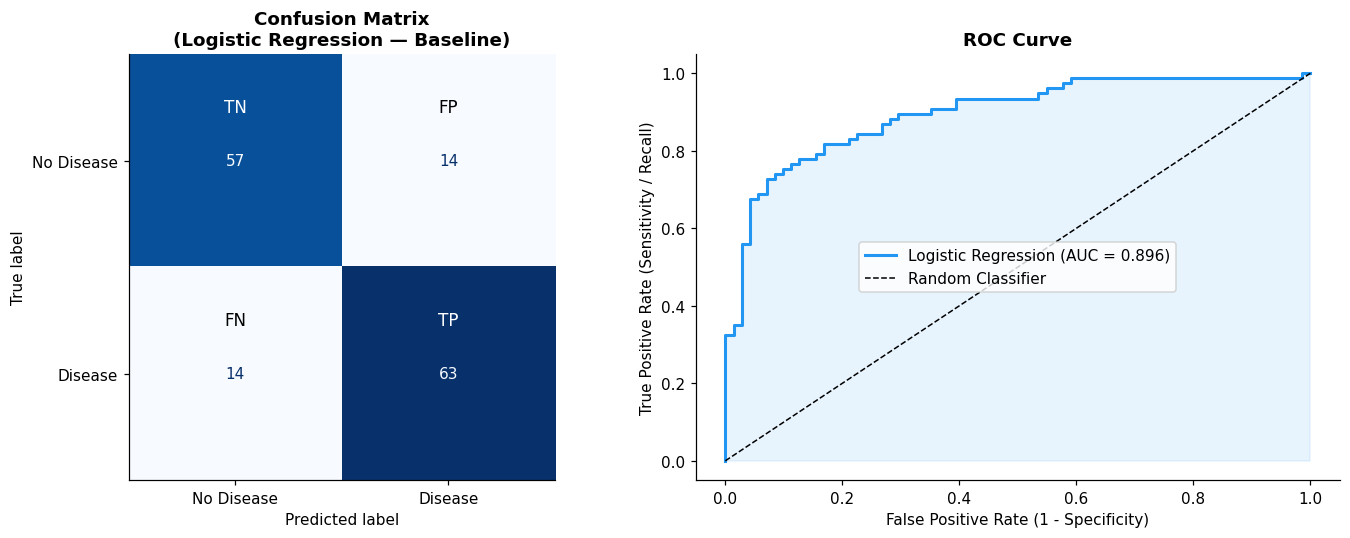


AUC-ROC: 0.8965  (1.0 = perfect, 0.5 = random)


In [12]:
# ── Confusion Matrix & ROC Curve ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix\n(Logistic Regression — Baseline)", fontweight='bold')

# Annotate with TP/TN/FP/FN labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i - 0.25, labels[i][j],
                     ha='center', va='center', fontsize=11,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('confusion_roc.png', bbox_inches='tight')
plt.show()

print(f"\nAUC-ROC: {roc_auc:.4f}  (1.0 = perfect, 0.5 = random)")


---
### 2.6 Understanding Probability Outputs & Decision Thresholds

The logistic regression model outputs a **probability**, not a hard class label.  
The default threshold is **0.5** — but this is a hyperparameter we can tune.

**Why change the threshold?**
- **Lower threshold (e.g., 0.3)**: More patients flagged as diseased → higher Recall, lower Precision  
- **Higher threshold (e.g., 0.7)**: Fewer false alarms → higher Precision, lower Recall

In a **disease screening** context, we usually prefer a **lower threshold** to catch more true cases,  
even at the cost of some false alarms that can be cleared by follow-up tests.

---


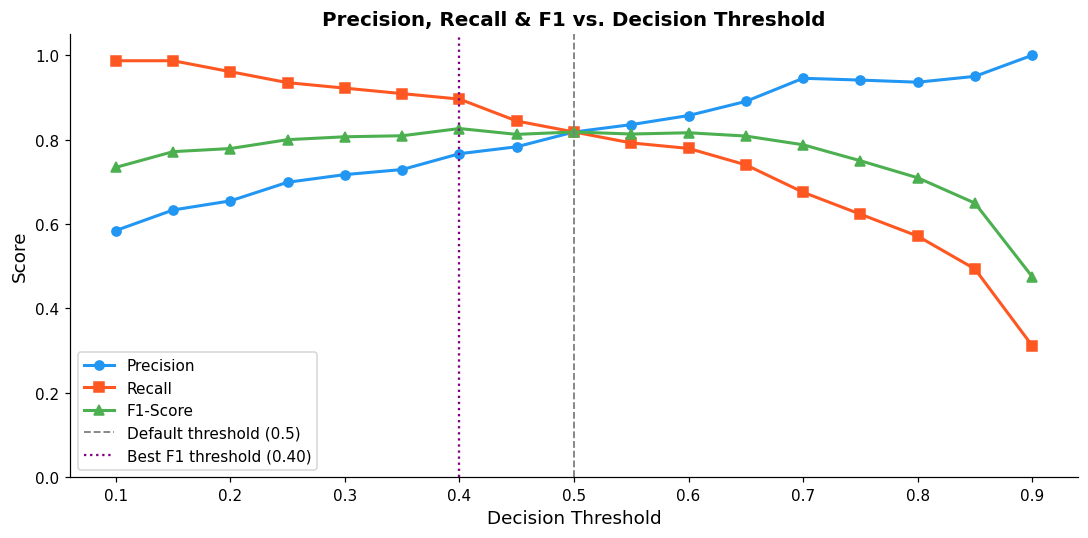


At default threshold 0.5 → F1: 0.818
Best F1 = 0.826 at threshold = 0.40


In [13]:
# ── Threshold Analysis ───────────────────────────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_t = (y_pred_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, 'o-', label='Precision', color='#2196F3', lw=2)
ax.plot(thresholds, recalls,    's-', label='Recall',    color='#FF5722', lw=2)
ax.plot(thresholds, f1s,        '^-', label='F1-Score',  color='#4CAF50', lw=2)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Default threshold (0.5)')

# Highlight best F1
best_idx = np.argmax(f1s)
ax.axvline(thresholds[best_idx], color='purple', linestyle=':', linewidth=1.5,
           label=f'Best F1 threshold ({thresholds[best_idx]:.2f})')

ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall & F1 vs. Decision Threshold", fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight')
plt.show()

print(f"\nAt default threshold 0.5 → F1: {f1s[list(thresholds).index(0.5) if 0.5 in list(thresholds) else np.argmin(abs(thresholds-0.5))]:.3f}")
print(f"Best F1 = {f1s[best_idx]:.3f} at threshold = {thresholds[best_idx]:.2f}")


---
### 2.7 Feature Importance in Logistic Regression

In logistic regression, the **coefficient** (weight) of each feature tells us:
- **Sign**: positive → higher value increases probability of class 1; negative → decreases it
- **Magnitude**: larger absolute value → stronger influence on the prediction

> Note: Coefficients are only comparable when features are **scaled to the same range** (which we did with StandardScaler).

---


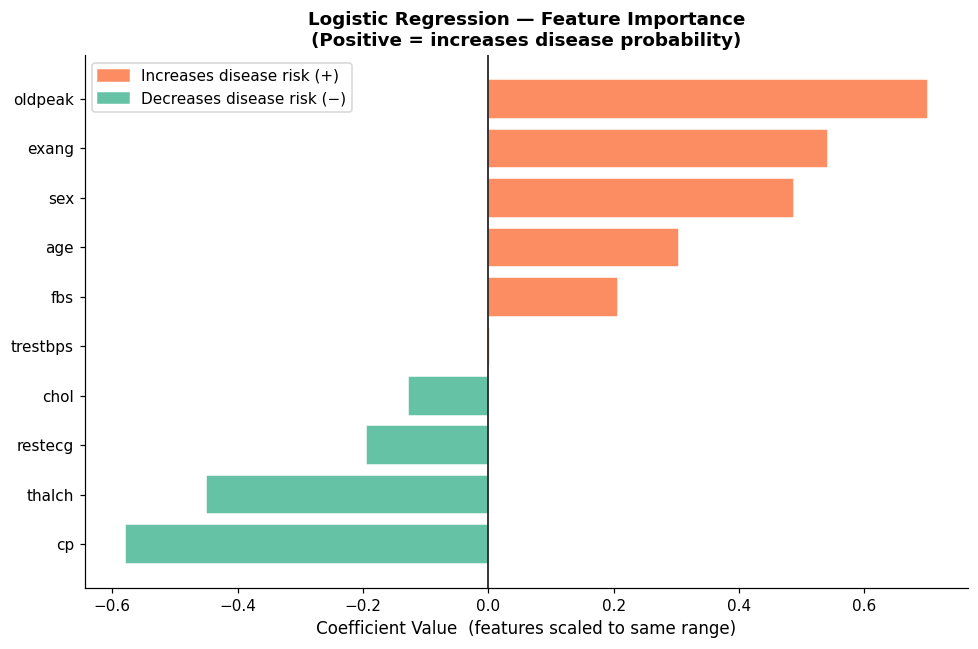


Top 3 risk-INCREASING features:
Feature  Coefficient
    sex     0.487514
  exang     0.541399
oldpeak     0.701327

Top 3 risk-DECREASING features:
Feature  Coefficient
     cp    -0.580033
 thalch    -0.450539
restecg    -0.195397


In [14]:
# ── Feature Importance (Coefficients) ────────────────────────────────────────

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['#fc8d62' if c > 0 else '#66c2a5' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("Coefficient Value  (features scaled to same range)", fontsize=11)
ax.set_title("Logistic Regression — Feature Importance\n(Positive = increases disease probability)", fontweight='bold')

# Legend
orange_p = mpatches.Patch(color='#fc8d62', label='Increases disease risk (+)')
green_p  = mpatches.Patch(color='#66c2a5', label='Decreases disease risk (−)')
ax.legend(handles=[orange_p, green_p], fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 3 risk-INCREASING features:")
print(coef_df.tail(3)[['Feature','Coefficient']].to_string(index=False))
print("\nTop 3 risk-DECREASING features:")
print(coef_df.head(3)[['Feature','Coefficient']].to_string(index=False))


---
### 2.8 Multiclass Logistic Regression

Our target `num` has 5 classes (0–4). Logistic regression handles this via two strategies:

- **One-vs-Rest (OvR)**: Train one binary classifier per class (class k vs. all others). Default in sklearn.
- **Multinomial (Softmax)**: Train a single model that outputs a probability distribution across all classes simultaneously.

The **softmax function** generalises the sigmoid to multiple classes:

$$P(y = k | x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

---


In [15]:
# ── Multiclass Logistic Regression ───────────────────────────────────────────

# Use original num column as target (severity 0-4)
df_mc = df_raw.copy()
df_mc.drop(columns=['ca', 'thal', 'slope', 'id', 'dataset'], inplace=True)
df_mc.dropna(inplace=True)

for col in ['fbs', 'exang']:
    df_mc[col] = df_mc[col].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})

cat_cols_mc = df_mc.select_dtypes(include='object').columns.tolist()
for col in cat_cols_mc:
    df_mc[col] = LabelEncoder().fit_transform(df_mc[col].astype(str))

X_mc = df_mc.drop(columns=['num'])
y_mc = df_mc['num']

X_tr_mc, X_ts_mc, y_tr_mc, y_ts_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)
scaler_mc = StandardScaler()
X_tr_mc_sc = scaler_mc.fit_transform(X_tr_mc)
X_ts_mc_sc = scaler_mc.transform(X_ts_mc)

lr_mc = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
lr_mc.fit(X_tr_mc_sc, y_tr_mc)
y_pred_mc = lr_mc.predict(X_ts_mc_sc)

print("=" * 55)
print("    MULTICLASS LOGISTIC REGRESSION — REPORT")
print("=" * 55)
print(classification_report(
    y_ts_mc, y_pred_mc,
    target_names=[f"Severity {i}" for i in range(5)],
    zero_division=0
))


    MULTICLASS LOGISTIC REGRESSION — REPORT
              precision    recall  f1-score   support

  Severity 0       1.00      1.00      1.00        71
  Severity 1       0.61      0.95      0.74        41
  Severity 2       0.50      0.06      0.11        16
  Severity 3       0.36      0.25      0.30        16
  Severity 4       0.00      0.00      0.00         4

    accuracy                           0.78       148
   macro avg       0.49      0.45      0.43       148
weighted avg       0.74      0.78      0.73       148



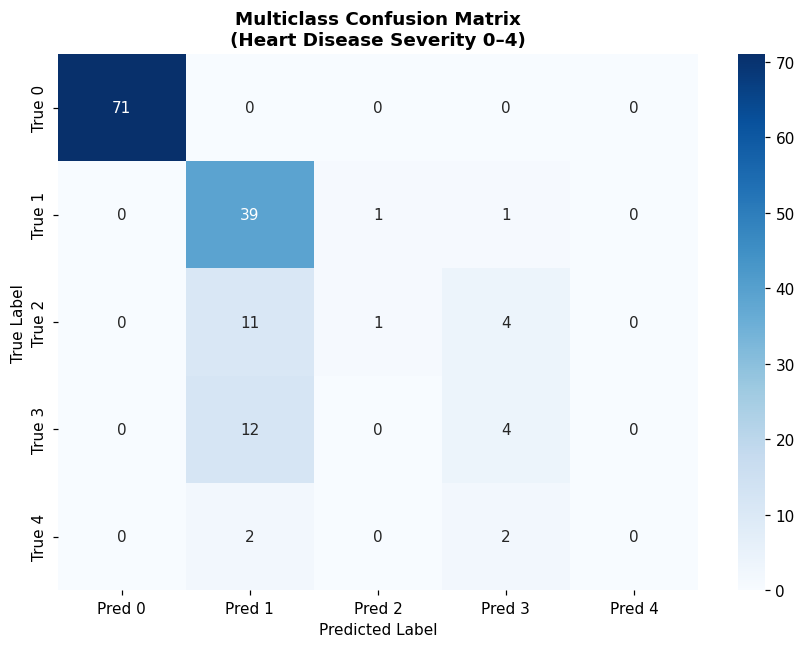


Observation: Classes 2, 3, 4 have very few samples — model struggles to learn them.
This motivates Section 3: Handling Imbalanced Datasets.


In [16]:
# ── Multiclass Confusion Matrix ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))
cm_mc = confusion_matrix(y_ts_mc, y_pred_mc)
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'True {i}' for i in range(5)])
ax.set_title("Multiclass Confusion Matrix\n(Heart Disease Severity 0–4)", fontweight='bold')
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig('multiclass_cm.png', bbox_inches='tight')
plt.show()

print("\nObservation: Classes 2, 3, 4 have very few samples — model struggles to learn them.")
print("This motivates Section 3: Handling Imbalanced Datasets.")


---
## 📚 Section 3 — Handling Imbalanced Datasets *(~30 mins)*

---

### 3.1 What Is Class Imbalance?

A dataset is **imbalanced** when one class has significantly more samples than another.

| Imbalance Ratio | Description |
|-----------------|-------------|
| 70:30 | Mild — usually fine |
| 90:10 | Moderate — start worrying |
| 95:5 | Severe — model will ignore minority |
| 99:1 | Extreme — e.g., fraud detection |

**Why is it a problem?**

A naive model that predicts "No Disease" for **every patient** achieves:
- 55% accuracy on our dataset (411 out of 740 samples)  
- But it has **0% recall** for the disease class — completely useless clinically!

This is called the **accuracy paradox**.

---

### 3.2 Identifying Imbalance

Always check your class distribution immediately after loading any dataset:
- `df['target'].value_counts()`
- `df['target'].value_counts(normalize=True)` (as percentages)
- Plot it!

---


Original dataset class distribution:
target
1    383
0    357
Name: count, dtype: int64
  Ratio: 0.9:1

Artificially imbalanced dataset:
target
0    357
1     96
Name: count, dtype: int64
  Ratio: 3.7:1


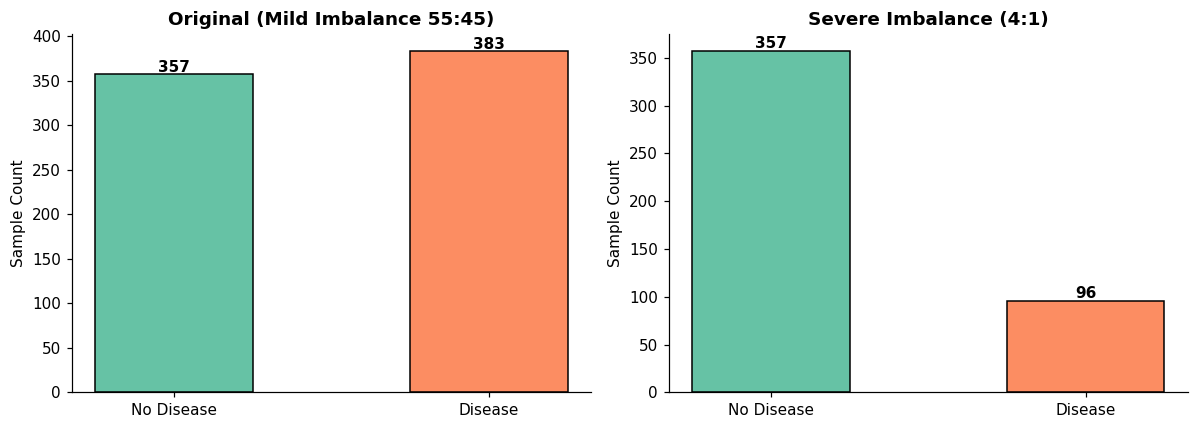

In [17]:
# ── Create an artificially imbalanced version for demonstration ───────────────

# Our binary dataset is mildly imbalanced (55:45).
# We'll create a more severe imbalance by undersampling the minority class
# to simulate what happens in fraud detection or rare disease datasets.

df_binary = df.copy()

# Separate classes
df_majority = df_binary[df_binary['target'] == 0]   # No disease
df_minority = df_binary[df_binary['target'] == 1]   # Disease

# Create severely imbalanced dataset: keep all majority, take 20% of minority
np.random.seed(42)
df_minority_small = df_minority.sample(frac=0.25, random_state=42)
df_imbalanced = pd.concat([df_majority, df_minority_small])

print("Original dataset class distribution:")
print(df_binary['target'].value_counts())
print(f"  Ratio: {df_binary['target'].value_counts()[0] / df_binary['target'].value_counts()[1]:.1f}:1\n")

print("Artificially imbalanced dataset:")
print(df_imbalanced['target'].value_counts())
ratio = df_imbalanced['target'].value_counts()[0] / df_imbalanced['target'].value_counts()[1]
print(f"  Ratio: {ratio:.1f}:1")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(
    axes,
    [df_binary, df_imbalanced],
    ["Original (Mild Imbalance 55:45)", f"Severe Imbalance ({ratio:.0f}:1)"]
):
    counts = data['target'].value_counts().sort_index()
    ax.bar(['No Disease', 'Disease'], counts.values,
           color=['#66c2a5', '#fc8d62'], edgecolor='black', width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel("Sample Count")

plt.tight_layout()
plt.savefig('imbalance_compare.png', bbox_inches='tight')
plt.show()


---
### 3.3 Techniques for Handling Imbalance

There are three main categories of solutions:

#### A. Resampling Methods

| Method | What it does | Trade-off |
|--------|-------------|-----------|
| **Oversampling** | Duplicates minority samples randomly | Risk of overfitting |
| **SMOTE** | Creates *synthetic* minority samples by interpolating between real ones | Better than random duplication |
| **Undersampling** | Removes majority samples randomly | Loses information |

#### B. Algorithm-Level Methods

| Method | How it works |
|--------|-------------|
| **Class weights** | Penalises misclassifying minority class more heavily during training |
| **Threshold tuning** | Move the decision boundary toward the majority class |

#### C. Ensemble Methods
- **BalancedRandomForest**, **EasyEnsemble** — combine resampling with ensemble models

---

### 3.4 SMOTE — Synthetic Minority Oversampling Technique

SMOTE creates new synthetic samples for the minority class:
1. For each minority sample, find its k nearest neighbours (in feature space)
2. Randomly pick one of those neighbours
3. Create a new point **along the line** between the original sample and the chosen neighbour

This avoids simple duplication and adds diversity to the minority class.

---


In [18]:
# ── Manual SMOTE Implementation (simplified) ─────────────────────────────────
# Since imbalanced-learn may not be installed, we implement the core idea.

def simple_smote(X_minority, n_synthetic, k=5, random_state=42):
    """
    Simplified SMOTE: generate n_synthetic new samples for the minority class.
    For each new sample:
      1. Pick a random minority sample
      2. Find k nearest neighbours within the minority class
      3. Pick a random neighbour
      4. Interpolate at a random point between the two
    """
    rng = np.random.RandomState(random_state)
    X = np.array(X_minority)
    synthetic = []

    for _ in range(n_synthetic):
        idx = rng.randint(0, len(X))
        sample = X[idx]

        # Find k nearest neighbours (Euclidean distance)
        dists = np.linalg.norm(X - sample, axis=1)
        dists[idx] = np.inf   # exclude self
        nn_indices = np.argsort(dists)[:k]

        # Pick a random neighbour
        nn_idx = rng.choice(nn_indices)
        neighbour = X[nn_idx]

        # Interpolate
        gap = rng.random()
        new_sample = sample + gap * (neighbour - sample)
        synthetic.append(new_sample)

    return np.array(synthetic)


# ── Apply to our imbalanced dataset ──────────────────────────────────────────

X_imb = df_imbalanced.drop(columns=['target']).values
y_imb = df_imbalanced['target'].values

# Scale first
scaler_imb = StandardScaler()
X_imb_sc = scaler_imb.fit_transform(X_imb)

X_maj = X_imb_sc[y_imb == 0]
X_min = X_imb_sc[y_imb == 1]

n_majority   = len(X_maj)
n_minority   = len(X_min)
n_to_create  = n_majority - n_minority   # balance the classes

print(f"Majority class size: {n_majority}")
print(f"Minority class size: {n_minority}")
print(f"Synthetic samples to create: {n_to_create}")

X_synthetic = simple_smote(X_min, n_to_create, k=5, random_state=42)
y_synthetic = np.ones(n_to_create, dtype=int)

X_smote = np.vstack([X_maj, X_min, X_synthetic])
y_smote = np.hstack([np.zeros(n_majority, dtype=int),
                     np.ones(n_minority, dtype=int),
                     y_synthetic])

print(f"\nAfter SMOTE — Class distribution:")
unique, counts = np.unique(y_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")


Majority class size: 357
Minority class size: 96
Synthetic samples to create: 261

After SMOTE — Class distribution:
  Class 0: 357
  Class 1: 357


In [19]:
# ── Undersampling Implementation ─────────────────────────────────────────────

def random_undersample(X_majority, X_minority, random_state=42):
    """Reduce majority class to match minority class size."""
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X_majority), size=len(X_minority), replace=False)
    return X_majority[idx]

X_maj_under = random_undersample(X_maj, X_min, random_state=42)

X_under = np.vstack([X_maj_under, X_min])
y_under = np.hstack([np.zeros(len(X_maj_under), dtype=int),
                     np.ones(len(X_min), dtype=int)])

print("After Undersampling — Class distribution:")
unique, counts = np.unique(y_under, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")
print(f"  Total samples remaining: {len(y_under)}")


After Undersampling — Class distribution:
  Class 0: 96
  Class 1: 96
  Total samples remaining: 192


---
### 3.5 Class Weight Adjustment

Instead of resampling, we can tell the model to **penalise misclassification of the minority class more**.

In sklearn's `LogisticRegression`:
- `class_weight='balanced'` automatically sets weights inversely proportional to class frequency
- Weight for class $k$ = $\frac{n_{samples}}{n_{classes} \times n_{samples\_of\_class\_k}}$

This means the minority class gets a higher weight → the model cares more about getting it right.

---


In [ ]:
# ── Compare all 4 strategies on the imbalanced dataset ──────────────────────

# Train/test split on imbalanced data BEFORE any resampling
# (Critical: only balance the TRAINING set, never the test set!)

X_tr_i, X_ts_i, y_tr_i, y_ts_i = train_test_split(
    X_imb_sc, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

# Recreate SMOTE / undersample only on training data
X_min_tr = X_tr_i[y_tr_i == 1]
X_maj_tr = X_tr_i[y_tr_i == 0]
n_create  = len(X_maj_tr) - len(X_min_tr)

# SMOTE training data
X_syn_tr  = simple_smote(X_min_tr, n_create, k=min(5, len(X_min_tr)-1), random_state=42)
X_smote_tr = np.vstack([X_maj_tr, X_min_tr, X_syn_tr])
y_smote_tr = np.hstack([np.zeros(len(X_maj_tr)), np.ones(len(X_min_tr)+n_create)])

# Undersample training data
idx_und    = np.random.RandomState(42).choice(len(X_maj_tr), size=len(X_min_tr), replace=False)
X_under_tr = np.vstack([X_maj_tr[idx_und], X_min_tr])
y_under_tr = np.hstack([np.zeros(len(X_min_tr)), np.ones(len(X_min_tr))])

# Random oversampling (duplicate minority)
n_dup       = len(X_maj_tr) - len(X_min_tr)
dup_idx     = np.random.RandomState(42).choice(len(X_min_tr), size=n_dup, replace=True)
X_over_tr   = np.vstack([X_maj_tr, X_min_tr, X_min_tr[dup_idx]])
y_over_tr   = np.hstack([np.zeros(len(X_maj_tr)), np.ones(len(X_min_tr)+n_dup)])

# Define strategies
strategies = {
    "No Balancing (Baseline)":    (X_tr_i,    y_tr_i),
    "Class Weights (balanced)":   (X_tr_i,    y_tr_i),
    "Random Oversampling":        (X_over_tr, y_over_tr),
    "SMOTE":                      (X_smote_tr,y_smote_tr),
    "Random Undersampling":       (X_under_tr,y_under_tr),
}

results = {}
for name, (X_tr_, y_tr_) in strategies.items():
    cw = 'balanced' if name == "Class Weights (balanced)" else None
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight=cw)
    model.fit(X_tr_, y_tr_)
    y_p = model.predict(X_ts_i)
    y_prob = model.predict_proba(X_ts_i)[:, 1]
    results[name] = {
        'accuracy':  (y_p == y_ts_i).mean(),
        'recall_1':  recall_score(y_ts_i, y_p, pos_label=1, zero_division=0),
        'precision_1': precision_score(y_ts_i, y_p, pos_label=1, zero_division=0),
        'f1_1':      f1_score(y_ts_i, y_p, pos_label=1, zero_division=0),
        'auc':       auc(*roc_curve(y_ts_i, y_prob)[:2])
    }

results_df = pd.DataFrame(results).T
print(results_df.round(3).to_string())


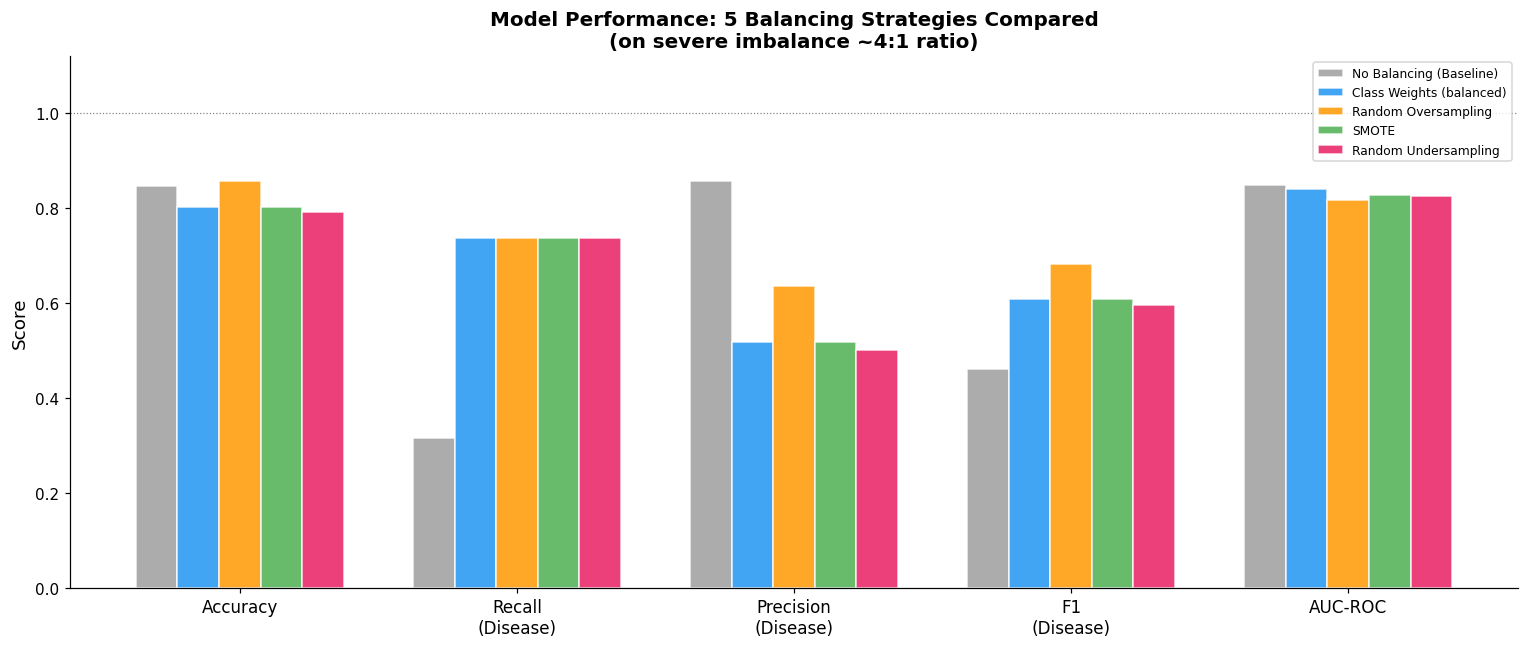


📝 KEY INSIGHT:
  • The baseline model gets high accuracy but low recall for the minority class.
  • Balancing techniques trade some accuracy for much better recall on the disease class.
  • In medical settings, higher recall (catch real cases) is usually worth the trade-off.


In [ ]:
# ── Visual Comparison of Balancing Strategies ────────────────────────────────

metrics = ['accuracy', 'recall_1', 'precision_1', 'f1_1', 'auc']
metric_labels = ['Accuracy', 'Recall\n(Disease)', 'Precision\n(Disease)', 'F1\n(Disease)', 'AUC-ROC']

x = np.arange(len(metrics))
width = 0.15
strategy_names = list(results_df.index)
colors = ['#9E9E9E', '#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (strategy, color) in enumerate(zip(strategy_names, colors)):
    vals = results_df.loc[strategy, metrics].values
    offset = (i - len(strategy_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=strategy, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance: 5 Balancing Strategies Compared\n(on severe imbalance ~4:1 ratio)",
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig('balancing_comparison.png', bbox_inches='tight')
plt.show()

print("\n📝 KEY INSIGHT:")
print("  • The baseline model gets high accuracy but low recall for the minority class.")
print("  • Balancing techniques trade some accuracy for much better recall on the disease class.")
print("  • In medical settings, higher recall (catch real cases) is usually worth the trade-off.")


In [ ]:
# ── Confusion Matrices Side by Side ─────────────────────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (name, (X_tr_, y_tr_)) in zip(axes, strategies.items()):
    cw = 'balanced' if name == "Class Weights (balanced)" else None
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight=cw)
    model.fit(X_tr_, y_tr_)
    y_p = model.predict(X_ts_i)
    cm_s = confusion_matrix(y_ts_i, y_p)
    sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                cbar=False)
    short = name.replace(" (balanced)", "")
    ax.set_title(short, fontsize=9, fontweight='bold')

plt.suptitle("Confusion Matrices — All Balancing Strategies", fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', bbox_inches='tight')
plt.show()


---
## 📚 Section 4 — Full Pipeline on Original Binary Data

Let's now put everything together on our **original binary heart disease dataset** (mild imbalance 55:45), applying the best practices we've learned.

---


In [ ]:
# ── Complete Best-Practice Pipeline ──────────────────────────────────────────

print("=" * 60)
print("   COMPLETE ML CLASSIFICATION PIPELINE")
print("   Dataset: UCI Heart Disease (Binary)")
print("=" * 60)

# 1. Data
X_final = df.drop(columns=['target'])
y_final = df['target']

# 2. Split (stratified to preserve class ratio)
X_tr_f, X_ts_f, y_tr_f, y_ts_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 3. Scale
sc_f = StandardScaler()
X_tr_f_sc = sc_f.fit_transform(X_tr_f)
X_ts_f_sc = sc_f.transform(X_ts_f)

# 4. Train with class_weight='balanced' (robust to mild imbalance)
best_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    C=1.0   # regularisation strength (default)
)
best_model.fit(X_tr_f_sc, y_tr_f)

# 5. Evaluate
y_pred_f    = best_model.predict(X_ts_f_sc)
y_prob_f    = best_model.predict_proba(X_ts_f_sc)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_ts_f, y_pred_f, target_names=['No Disease', 'Disease']))

fpr_f, tpr_f, _ = roc_curve(y_ts_f, y_prob_f)
print(f"AUC-ROC: {auc(fpr_f, tpr_f):.4f}")


In [ ]:
# ── Final Summary Dashboard ──────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))

# 1. Confusion matrix
ax1 = fig.add_subplot(2, 3, 1)
cm_f = confusion_matrix(y_ts_f, y_pred_f)
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred: No Disease', 'Pred: Disease'],
            yticklabels=['True: No Disease', 'True: Disease'], cbar=False)
ax1.set_title("Confusion Matrix", fontweight='bold')

# 2. ROC curve
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(fpr_f, tpr_f, lw=2, color='#2196F3', label=f'AUC = {auc(fpr_f, tpr_f):.3f}')
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.fill_between(fpr_f, tpr_f, alpha=0.1, color='#2196F3')
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR"); ax2.set_title("ROC Curve", fontweight='bold')
ax2.legend()

# 3. Feature importance
ax3 = fig.add_subplot(2, 3, 3)
coef_f = pd.DataFrame({'Feature': X_final.columns, 'Coef': best_model.coef_[0]})
coef_f = coef_f.sort_values('Coef')
colors_f = ['#fc8d62' if c > 0 else '#66c2a5' for c in coef_f['Coef']]
ax3.barh(coef_f['Feature'], coef_f['Coef'], color=colors_f)
ax3.axvline(0, color='black', lw=1)
ax3.set_title("Feature Importance", fontweight='bold')

# 4. Probability distribution
ax4 = fig.add_subplot(2, 3, 4)
prob_0 = y_prob_f[y_ts_f == 0]
prob_1 = y_prob_f[y_ts_f == 1]
ax4.hist(prob_0, bins=20, alpha=0.6, color='#66c2a5', label='No Disease', density=True)
ax4.hist(prob_1, bins=20, alpha=0.6, color='#fc8d62', label='Disease', density=True)
ax4.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
ax4.set_xlabel("Predicted Probability"); ax4.set_ylabel("Density")
ax4.set_title("Probability Distributions by Class", fontweight='bold')
ax4.legend()

# 5. Precision-Recall tradeoff
ax5 = fig.add_subplot(2, 3, 5)
ths = np.arange(0.1, 0.91, 0.05)
precs_f, recs_f, f1s_f = [], [], []
for t in ths:
    yp = (y_prob_f >= t).astype(int)
    precs_f.append(precision_score(y_ts_f, yp, zero_division=0))
    recs_f.append(recall_score(y_ts_f, yp, zero_division=0))
    f1s_f.append(f1_score(y_ts_f, yp, zero_division=0))

ax5.plot(ths, precs_f, 'o-', label='Precision', lw=1.5)
ax5.plot(ths, recs_f, 's-', label='Recall', lw=1.5)
ax5.plot(ths, f1s_f, '^-', label='F1', lw=1.5)
ax5.axvline(0.5, color='gray', linestyle='--', lw=1)
ax5.set_xlabel("Threshold"); ax5.set_title("Threshold Analysis", fontweight='bold')
ax5.legend()

# 6. Summary text box
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = [
    "✅  PIPELINE SUMMARY",
    "",
    f"Dataset:      UCI Heart Disease",
    f"Samples:      {len(y_final)} (after cleaning)",
    f"Features:     {X_final.shape[1]}",
    f"Imbalance:    55:45 (mild)",
    "",
    f"Strategy:     Class Weight Balancing",
    f"Model:        Logistic Regression",
    "",
    f"Accuracy:     {(y_pred_f == y_ts_f).mean():.3f}",
    f"F1 (Disease): {f1_score(y_ts_f, y_pred_f):.3f}",
    f"AUC-ROC:      {auc(fpr_f, tpr_f):.3f}",
    f"Recall:       {recall_score(y_ts_f, y_pred_f):.3f}",
    "",
    "💡 Higher recall = fewer missed cases",
]
ax6.text(0.05, 0.95, '\n'.join(summary),
         transform=ax6.transAxes, fontsize=10.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))

plt.suptitle("Final Model Dashboard — Heart Disease Classification", fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('final_dashboard.png', bbox_inches='tight')
plt.show()


---
## 📝 Classification Project Assignment

---

### Project Domains

Choose **one** domain and build a baseline logistic regression model:

| # | Domain | Dataset Sources | Target Variable |
|---|--------|-----------------|-----------------|
| 1 | 🏥 **Disease Diagnosis** | UCI Repository, Kaggle Health | Positive / Negative |
| 2 | 📞 **Customer Churn** | Kaggle Telco Churn, IBM HR | Churn / No Churn |
| 3 | 💳 **Fraud Detection** | Kaggle Credit Card Fraud | Fraud / Legitimate |
| 4 | 🏦 **Credit Risk** | Give Me Some Credit (Kaggle) | Default / No Default |
| 5 | 💬 **Sentiment Analysis** | Twitter API, Kaggle NLP | Positive / Negative / Neutral |

---

### Deliverables

For your selected domain, submit a notebook with **all 5 steps**:

**Step 1 — Dataset Selection**
- Load your chosen dataset
- State the source, number of rows, and number of features

**Step 2 — Exploratory Data Analysis**
- Show the class distribution (bar chart + percentages)
- Identify imbalance ratio
- Show missing value summary
- Plot 3–5 feature distributions coloured by class

**Step 3 — Preprocessing**
- Handle missing values (explain your strategy)
- Encode categorical features
- Scale numerical features
- Split into train/test with stratification

**Step 4 — Baseline Logistic Regression**
- Train logistic regression with default settings
- Evaluate with: accuracy, precision, recall, F1, AUC-ROC
- Plot the confusion matrix and ROC curve

**Step 5 — Handle Imbalance (if present)**
- Apply at least **two** balancing techniques
- Compare metrics in a table
- Recommend the best strategy for your use case and explain why

---

### Grading Rubric

| Criterion | Marks |
|-----------|-------|
| Clear EDA with class distribution analysis | 20 |
| Correct preprocessing pipeline | 20 |
| Working logistic regression with correct evaluation | 25 |
| Imbalance handling with comparison | 25 |
| Code quality, comments, and markdown explanations | 10 |
| **Total** | **100** |

---

### 💡 Quick-Start Template

```python
# Step 1: Load your data
df = pd.read_csv('your_dataset.csv')
print(df['target_column'].value_counts(normalize=True))

# Step 2: EDA
df['target_column'].value_counts().plot(kind='bar')
plt.title("Class Distribution"); plt.show()

# Step 3: Preprocess
# ... encode, scale, split ...

# Step 4: Baseline model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Step 5: Apply balancing (class_weight, oversampling, SMOTE, undersampling)
# Compare and discuss results
```

---

## 🎓 Key Takeaways

| Concept | What You Learned |
|---------|-----------------|
| **Classification** | Predicting discrete categories; differs from regression in output type and metrics |
| **Logistic Regression** | Uses sigmoid to output probabilities; decision boundary is linear |
| **Coefficients** | Tell us which features increase/decrease class probability |
| **Thresholds** | Default is 0.5 but adjusting it trades precision for recall |
| **Imbalance** | High accuracy ≠ good model; check recall for minority class |
| **SMOTE** | Creates synthetic minority samples by interpolation |
| **Class Weights** | Tells model to penalise minority misclassification more |
| **Always** | Split before resampling; never balance the test set! |

---

*Notebook prepared by ML Foundations Course · UCI Heart Disease Dataset · 2024*
